# Sharp corners: a periodic array of triangles against a Fourier reference

Polygons are the stress test of an analytic wall: the exact kernel integrals are available for any polygon (the corner quadrant is not special), but the *no-slip closure* assumes the wall is locally a
plane or a smooth curve, which a corner violates. The rig is a periodic array of one isosceles triangle (apex angle $\beta$, any rotation) in Stokes flow, driven by a body force on the fluid, against an
independent reference of the same cell: a volume-penalised Fourier–CG Stokes solve with a smoothed polygon indicator (`corner_rig.fourier`, cached on disk; a few minutes the first time).

Compared: the steady superficial velocity (both components: a rotated body gives a transverse flow) and the drag coefficient $K=F/(\mu U_x)$.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import math, os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.getcwd(), "..", "..", "scripts", "studies"))
import corner_rig as cr                       # polygon(), signed_distance(), fourier()

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.scene.periodic import Periodic
from warpSPHBoundaries.scene.scene import Body, Scene, SurfaceRep
from warpSPHBoundaries.sim.dfsph2d import carve, lattice_calibration, PACKING
from warpSPHBoundaries.sim.solvers import make_solver, lattice

n = {"quick": 32, "full": 48}[QUALITY]
beta, rot, c = 30.0, 0.0, 0.04                 # apex angle (deg), rotation (deg), area fraction of the cell (the body plus a support must fit half the cell)
nu, f, T = 0.0185, 0.03, {"quick": 30.0, "full": 40.0}[QUALITY]
Nref = {"quick": 256, "full": 384}[QUALITY]
dx = 1.0 / n

## The reference (penalised Fourier Stokes solve)

In [3]:
V = cr.polygon("triangle", c, beta=beta, rot=rot)
ref = cr.fourier(V, N=Nref)
Uref, Fref = ref["U"], ref["F"]                 # superficial velocity and force on the solid for nu = 1 and unit body force on the fluid
print(f"reference: U = ({Uref[0]:.5f}, {Uref[1]:.5f}),  K = F/(mu U_x) = {Fref[0] / Uref[0]:.3f}")

reference: U = (0.07055, -0.00000),  K = F/(mu U_x) = 13.594


## SPH run

In [4]:
pos = lattice((0, 0), (1, 1), dx)
body = Body(bodyId=0, center=(0.5, 0.5), reps=[SurfaceRep.polygon(V)])
if SCHEME == "delta":
    sd, _ = cr.signed_distance(pos - 0.5, V)
    pos = pos[sd >= 0.5 * dx]
else:
    cal = lattice_calibration(dx, dx, dx / PACKING)
    pos = carve(pos, [body], dx / PACKING, cal["lamCell"], DEVICE)
extra = {"maxDt": 1e-2} if SCHEME == "dfsph" else {}
sol = make_solver(SCHEME, pos, dx, Scene([body], DEVICE), nu=nu, bodyForce=(f, 0.0), periodic=Periodic((0, 0), (1, 1)), c0=10 * f / (nu * 5), device=DEVICE, **extra)
Fh, Uh = [], []
def record(s):
    Fh.append(s.loads(0)); Uh.append((s.time, (s.v * s.volume[:, None]).sum(0)))
sol.run(T, every=T / 3, callback=record, report=lambda s: f"U = ({Uh[-1][1][0]:.5f}, {Uh[-1][1][1]:+.5f})")

  t   10.000  dt 6.09e-03  vmax    0.176  U = (0.10413, -0.00000)  [78 s]


  t   20.000  dt 6.09e-03  vmax    0.202  U = (0.11821, +0.00000)  [171 s]


  t   30.001  dt 6.09e-03  vmax    0.206  U = (0.12004, +0.00005)  [265 s]


True

## Comparison

scheme delta, n = 32, N = 962
U_x / U_x,ref = 1.0493      U_y / U_x = +0.0004  (reference -0.0000)
K = 12.636   K_ref = 13.594   ratio 0.9296
F / balance = 1.0014


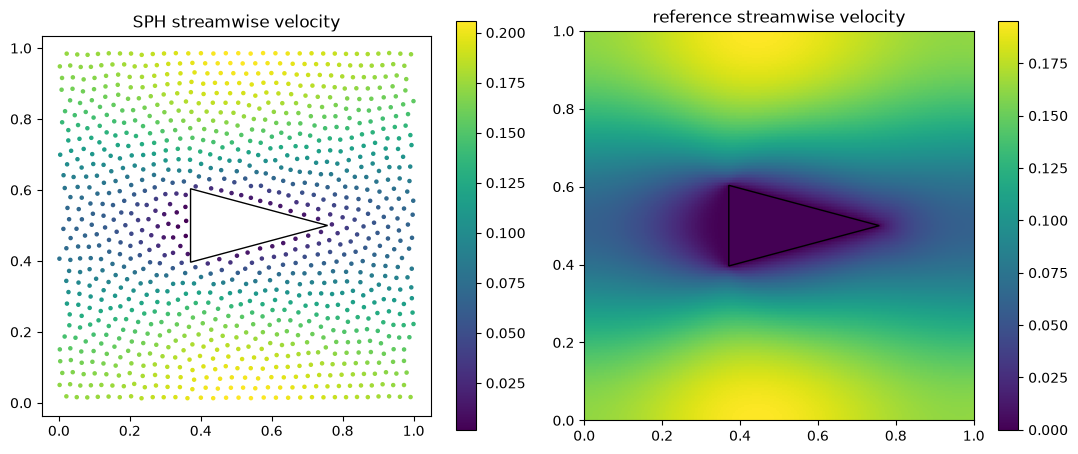

In [5]:
U = (sol.v * sol.volume[:, None]).sum(0)
F = np.mean(Fh[-300:], axis=0)
Uexp = f * Uref / nu                                     # the reference is linear in f and 1/nu (nu = 1, f = 1)
print(f"scheme {SCHEME}, n = {n}, N = {sol.n}")
print(f"U_x / U_x,ref = {U[0] / Uexp[0]:.4f}      U_y / U_x = {U[1] / U[0]:+.4f}  (reference {Uref[1] / Uref[0]:+.4f})")
print(f"K = {F[0] / (nu * U[0]):.3f}   K_ref = {Fref[0] / Uref[0]:.3f}   ratio {F[0] / (nu * U[0]) / (Fref[0] / Uref[0]):.4f}")
print(f"F / balance = {F[0] / (f * float(sol.volume.sum())):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
q = ax[0].scatter(np.mod(sol.x[:, 0], 1), np.mod(sol.x[:, 1], 1), c=sol.v[:, 0], s=5); ax[0].add_patch(plt.Polygon(V + 0.5, fill=False, color="k")); ax[0].set(aspect="equal", title="SPH streamwise velocity"); plt.colorbar(q, ax=ax[0])
N = ref["u"].shape[1]; xx = (np.arange(N) + 0.5) / N
im = ax[1].pcolormesh(xx, xx, ref["u"][0].T * f / nu, shading="auto"); ax[1].add_patch(plt.Polygon(V + 0.5, fill=False, color="k")); ax[1].set(aspect="equal", title="reference streamwise velocity"); plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

## What to look at

* the same Stokes problem as notebook 04, but the wall now has three sharp corners (the 30° apex is the worst); the flow and the load must still follow the reference;
* `QUALITY = "full"` uses a finer lattice and reference; the corner error converges more slowly than the smooth-wall error.